In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

C:\Users\Apoorv Bagga\AppData\Roaming\Python\Python310\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
batch_size = 64
image_size = 64

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

In [3]:
latent_dim = 100

In [4]:
class Generator(nn.Module):

    def __init__(self):
        super(Generator,self).__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(latent_dim,512,4,1,0,bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512,256,4,2,1,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,3,4,2,1,bias=False),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

In [5]:
generator = Generator()

# generator.load_state_dict(torch.load("generator.pth"))

generator.eval()

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [6]:
for param in generator.parameters():
    param.requires_grad = False

In [7]:
def generate_images(num_images=8):

    noise = torch.randn(num_images,latent_dim,1,1)

    with torch.no_grad():
        fake_images = generator(noise).detach().cpu()

    grid = torchvision.utils.make_grid(fake_images,nrow=4,normalize=True)

    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.show()

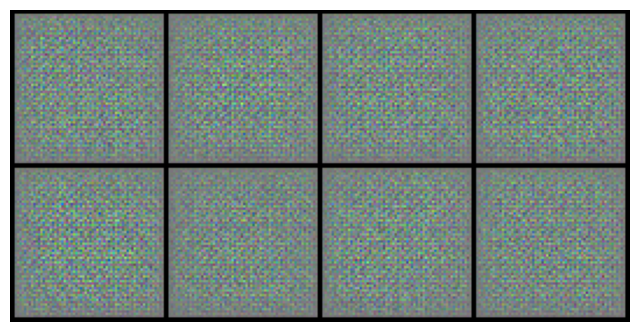

In [8]:
generate_images(8)

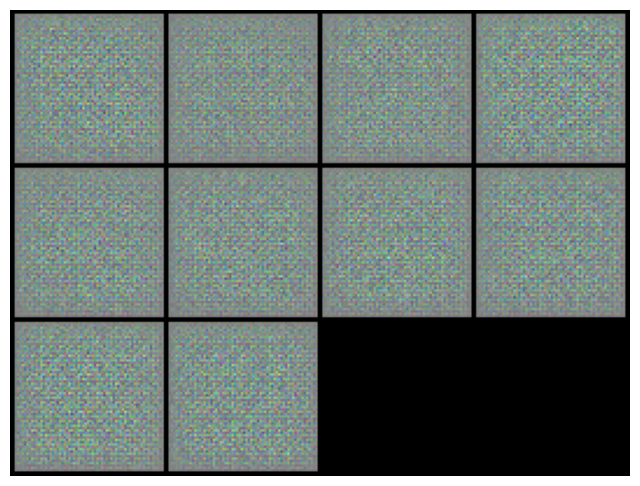

In [9]:
generate_images(10)

In [10]:
def interpolate(z1,z2,steps=10):

    vectors = []

    for alpha in np.linspace(0,1,steps):
        vec = (1-alpha)*z1 + alpha*z2
        vectors.append(vec)

    vectors = torch.stack(vectors)

    with torch.no_grad():
        images = generator(vectors).cpu()

    grid = torchvision.utils.make_grid(images,nrow=steps,normalize=True)

    plt.figure(figsize=(15,3))
    plt.axis("off")
    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.show()

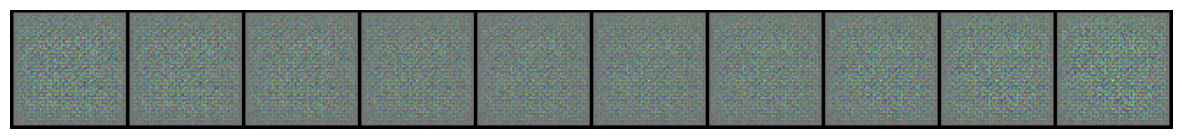

In [11]:
z1 = torch.randn(latent_dim,1,1)
z2 = torch.randn(latent_dim,1,1)

interpolate(z1,z2,10)

In [12]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

fatal: destination path 'stylegan2-ada-pytorch' already exists and is not an empty directory.


In [13]:
import sys
sys.path.append("./stylegan2-ada-pytorch")

In [14]:
import pickle
import urllib
import torch
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
url = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl"

with urllib.request.urlopen(url) as f:
    G = pickle.load(f)['G_ema']

Generating images...


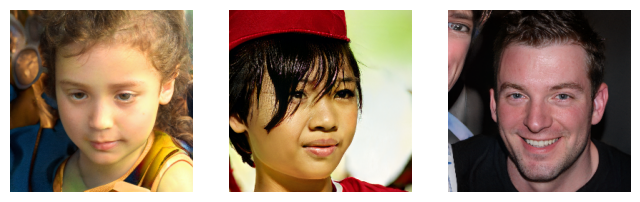

Done!


In [15]:
device = torch.device("cpu")
G = G.to(device)

print("Generating images...")

z = torch.randn(3, G.z_dim).to(device)   # only 3 images

with torch.no_grad():
    images = G(z, None)

# reduce resolution to make display faster
images = torch.nn.functional.interpolate(images, size=(256,256))

images = (images.permute(0,2,3,1).cpu().numpy()*127.5 + 128).clip(0,255).astype(np.uint8)

plt.figure(figsize=(8,4))

for i in range(len(images)):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

print("Done!")